In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/modelling-memristor-dataset/modelling_data.mat


In [2]:
import scipy.io
import numpy as np

# Load the dataset
file_path = '/kaggle/input/modelling-memristor-dataset/modelling_data.mat'
data = scipy.io.loadmat(file_path)

# Check what variables are inside
print(data.keys())


dict_keys(['__header__', '__version__', '__globals__', 'data', '__function_workspace__'])


In [4]:
mem_data = data['data']
print(type(mem_data))
print(mem_data.shape)


<class 'numpy.ndarray'>
(1, 1)


In [5]:
# Extract the single element
mem_data = data['data'][0, 0]

# Check its type
print(type(mem_data))


<class 'numpy.void'>


In [6]:
print(mem_data.dtype)  # If it's a structured array


[('Yakopcic', 'O'), ('MMS', 'O'), ('stat', 'O'), ('VTEAM', 'O')]


Yakopcic fields: ('Amp', 'Freq', 'Dop', 'Rs', 'U_m', 'I_m', 't', 'min_r', 'param', 'X', 'G', 'V', 'I', 'cost_function2compare', 'U_sin')


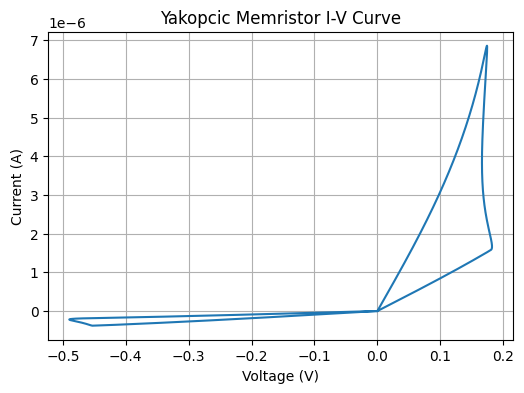

In [9]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
file_path = '/kaggle/input/modelling-memristor-dataset/modelling_data.mat'
data = scipy.io.loadmat(file_path)

# Extract main struct
mem_data = data['data'][0, 0]

# Extract Yakopcic model
yakopcic = mem_data['Yakopcic'][0, 0]

# Inspect fields
print("Yakopcic fields:", yakopcic.dtype.names)

# Extract voltage/current safely (unwrap nested arrays)
voltage = yakopcic['V'][0,0].flatten()  # 'V' might be the voltage array
current = yakopcic['I'][0,0].flatten()  # 'I' might be the current array

# Plot I-V curve
plt.figure(figsize=(6,4))
plt.plot(voltage, current)
plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("Yakopcic Memristor I-V Curve")
plt.grid(True)
plt.show()


In [11]:
import scipy.io

# Load the dataset
file_path = '/kaggle/input/modelling-memristor-dataset/modelling_data.mat'
data = scipy.io.loadmat(file_path)

# Extract main struct
mem_data = data['data'][0, 0]

# List of models
models = ['Yakopcic', 'MMS', 'stat', 'VTEAM']

# Check fields inside each model
for model in models:
    model_data = mem_data[model][0,0]  # unwrap 1x1 array
    print(f"{model} fields: {model_data.dtype.names}")


Yakopcic fields: ('Amp', 'Freq', 'Dop', 'Rs', 'U_m', 'I_m', 't', 'min_r', 'param', 'X', 'G', 'V', 'I', 'cost_function2compare', 'U_sin')
MMS fields: ('Amp', 'Freq', 'Dop', 'Rs', 'U_m', 'I_m', 't', 'min_r', 'param', 'X', 'G', 'V', 'I', 'cost_function2compare', 'U_sin')
stat fields: ('Amp', 'Freq', 'Dop', 'Rs', 'U_m', 'I_m', 't', 'std', 'wsk', 'eps', 'I_m_b_interp', 'U_m_b_interp', 'U_sin')
VTEAM fields: ('Amp', 'Freq', 'Dop', 'Rs', 'U_m', 'I_m', 't', 'min_r', 'param', 'a', 'X', 'G', 'V', 'I', 'cost_function2compare', 'U_sin')


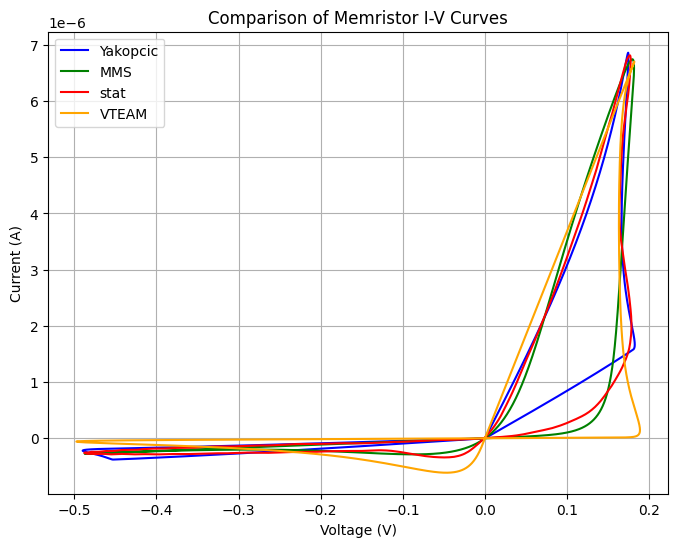

In [13]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
file_path = '/kaggle/input/modelling-memristor-dataset/modelling_data.mat'
data = scipy.io.loadmat(file_path)
mem_data = data['data'][0,0]

# Models to plot
models = ['Yakopcic', 'MMS', 'stat', 'VTEAM']
colors = ['blue', 'green', 'red', 'orange']

plt.figure(figsize=(8,6))

for model, color in zip(models, colors):
    model_data = mem_data[model][0,0]
    
    # Handle voltage/current fields
    if model == 'stat':
        voltage = model_data['U_m_b_interp'][0,0].flatten()
        current = model_data['I_m_b_interp'][0,0].flatten()
    else:
        voltage = model_data['V'][0,0].flatten()
        current = model_data['I'][0,0].flatten()
    
    plt.plot(voltage, current, label=model, color=color)

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("Comparison of Memristor I-V Curves")
plt.legend()
plt.grid(True)
plt.show()


In [14]:
for model in models:
    model_data = mem_data[model][0,0]
    if model == 'stat':
        voltage = model_data['U_m_b_interp'][0,0].flatten()
        current = model_data['I_m_b_interp'][0,0].flatten()
    else:
        voltage = model_data['V'][0,0].flatten()
        current = model_data['I'][0,0].flatten()
    resistance = voltage / current
    print(f"{model}: R_min={np.min(resistance):.3e}, R_max={np.max(resistance):.3e}")


Yakopcic: R_min=2.537e+04, R_max=2.466e+06
MMS: R_min=2.602e+04, R_max=1.777e+06
stat: R_min=-6.308e+04, R_max=9.895e+06
VTEAM: R_min=2.711e+04, R_max=1.299e+07


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Example: Yakopcic regression
yakopcic = mem_data['Yakopcic'][0,0]
voltage = yakopcic['V'][0,0].flatten()
current = yakopcic['I'][0,0].flatten()

X = voltage.reshape(-1,1)
y = current

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Yakopcic Regression MSE:", mse)


Yakopcic Regression MSE: 2.727866362431587e-12


Yakopcic Regression MSE: 2.72787e-12


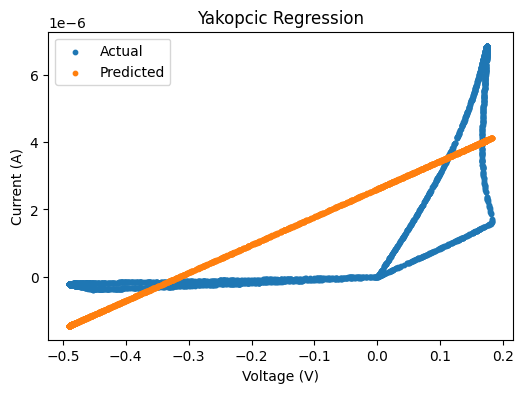

Yakopcic Classification Accuracy: 1.000


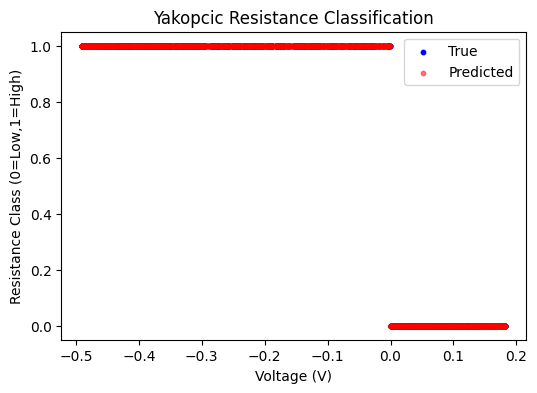

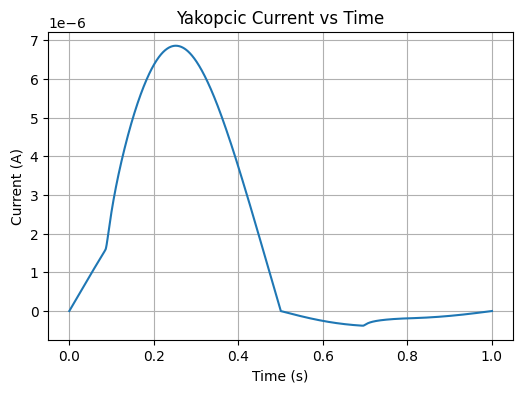

In [17]:
# Libraries
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score

# Load dataset
file_path = '/kaggle/input/modelling-memristor-dataset/modelling_data.mat'
data = scipy.io.loadmat(file_path)
mem_data = data['data'][0,0]

# Choose a model for ML (Yakopcic as example)
model_name = 'Yakopcic'
model_data = mem_data[model_name][0,0]

# Extract voltage and current
V = model_data['V'][0,0].flatten()
I = model_data['I'][0,0].flatten()

# ---------------------------
# Regression: Predict Current
# ---------------------------
X = V.reshape(-1,1)  # Feature: voltage
y = I                 # Target: current

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"{model_name} Regression MSE: {mse:.5e}")

# Plot predicted vs actual
plt.figure(figsize=(6,4))
plt.scatter(X_test, y_test, label="Actual", s=10)
plt.scatter(X_test, y_pred, label="Predicted", s=10)
plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title(f"{model_name} Regression")
plt.legend()
plt.show()

# ---------------------------
# Classification: High/Low Resistance
# ---------------------------
R = V / I
R_threshold = np.median(R)  # median as threshold
labels = (R > R_threshold).astype(int)  # 1 = High, 0 = Low

X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"{model_name} Classification Accuracy: {acc:.3f}")

# Plot classification results
plt.figure(figsize=(6,4))
plt.scatter(X_test, y_test, label="True", c='blue', s=10)
plt.scatter(X_test, y_pred, label="Predicted", c='red', s=10, alpha=0.5)
plt.xlabel("Voltage (V)")
plt.ylabel("Resistance Class (0=Low,1=High)")
plt.title(f"{model_name} Resistance Classification")
plt.legend()
plt.show()

# ---------------------------
# Time-dependent Analysis (Visualization)
# ---------------------------
t = model_data['t'][0,0].flatten()  # time array
plt.figure(figsize=(6,4))
plt.plot(t, I)
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.title(f"{model_name} Current vs Time")
plt.grid(True)
plt.show()


Διαθέσιμα μοντέλα: ('Yakopcic', 'MMS', 'stat', 'VTEAM')
Πεδία του Yakopcic: ('Amp', 'Freq', 'Dop', 'Rs', 'U_m', 'I_m', 't', 'min_r', 'param', 'X', 'G', 'V', 'I', 'cost_function2compare', 'U_sin')


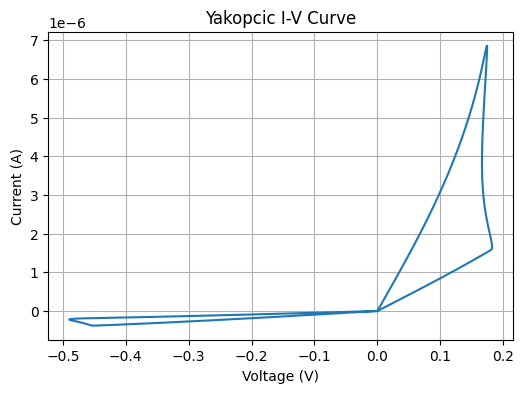

In [18]:
# Βήμα 1: Φόρτωση dataset και απλή εξερεύνηση
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Φόρτωση του .mat αρχείου
file_path = '/kaggle/input/modelling-memristor-dataset/modelling_data.mat'
data = scipy.io.loadmat(file_path)

# Εξαγωγή της βασικής δομής
mem_data = data['data'][0,0]

# Δες τα διαθέσιμα μοντέλα
models = mem_data.dtype.names
print("Διαθέσιμα μοντέλα:", models)

# Επιλογή μοντέλου για απλή πλοτάρισμα (Yakopcic)
model_name = 'Yakopcic'
model_data = mem_data[model_name][0,0]

# Δες τα πεδία του μοντέλου
print(f"Πεδία του {model_name}:", model_data.dtype.names)

# Εξαγωγή τάσης και ρεύματος (Voltage και Current)
V = model_data['V'][0,0].flatten()
I = model_data['I'][0,0].flatten()

# Απλό I-V plot
plt.figure(figsize=(6,4))
plt.plot(V, I)
plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title(f"{model_name} I-V Curve")
plt.grid(True)
plt.show()


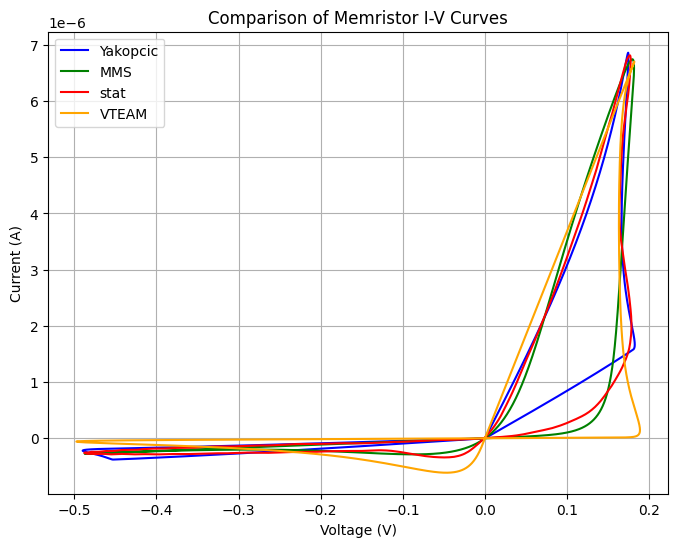

In [19]:
# Βήμα 2: Σύγκριση I-V curves για όλα τα μοντέλα
import matplotlib.pyplot as plt

# Χρώματα για κάθε μοντέλο
colors = ['blue', 'green', 'red', 'orange']

plt.figure(figsize=(8,6))

for model, color in zip(models, colors):
    model_data = mem_data[model][0,0]
    
    # Διαφορετική διαχείριση για το 'stat'
    if model == 'stat':
        voltage = model_data['U_m_b_interp'][0,0].flatten()
        current = model_data['I_m_b_interp'][0,0].flatten()
    else:
        voltage = model_data['V'][0,0].flatten()
        current = model_data['I'][0,0].flatten()
    
    plt.plot(voltage, current, label=model, color=color)

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("Comparison of Memristor I-V Curves")
plt.legend()
plt.grid(True)
plt.show()


Yakopcic Regression MSE: 2.72787e-12


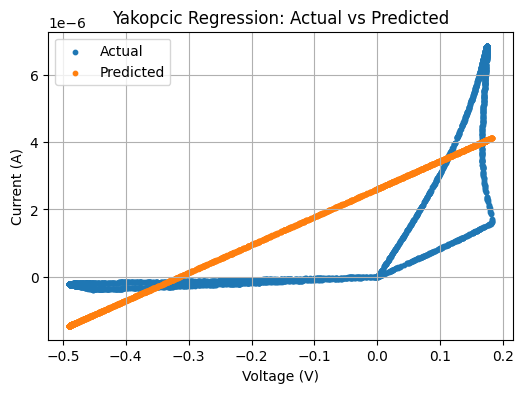

In [20]:
# Βήμα 3: Regression ML – Πρόβλεψη ρεύματος
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Επιλογή χαρακτηριστικών (X) και στόχου (y)
X = V.reshape(-1,1)  # τάση
y = I                 # ρεύμα

# Διαχωρισμός σε training και test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Εκπαίδευση Linear Regression
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# Πρόβλεψη στο test set
y_pred = reg_model.predict(X_test)

# Αξιολόγηση
mse = mean_squared_error(y_test, y_pred)
print(f"Yakopcic Regression MSE: {mse:.5e}")

# Σχεδίαση predicted vs actual
plt.figure(figsize=(6,4))
plt.scatter(X_test, y_test, label="Actual", s=10)
plt.scatter(X_test, y_pred, label="Predicted", s=10)
plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("Yakopcic Regression: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


Yakopcic Classification Accuracy: 1.000


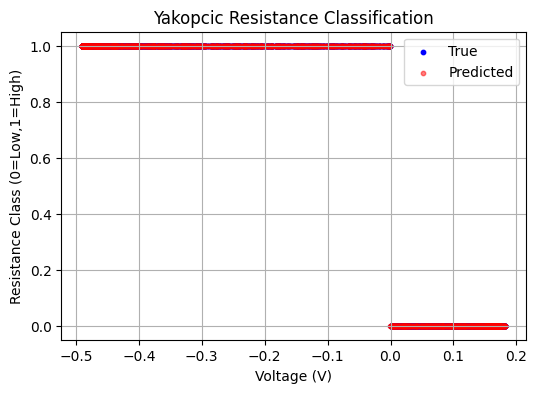

In [21]:
# Βήμα 4: Classification – High/Low Resistance
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Υπολογισμός αντίστασης
R = V / I

# Ορισμός threshold (median) για High/Low resistance
R_threshold = np.median(R)
labels = (R > R_threshold).astype(int)  # 1 = High, 0 = Low

# Διαχωρισμός σε train/test set
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=42)

# Εκπαίδευση Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Πρόβλεψη
y_pred = clf.predict(X_test)

# Αξιολόγηση
acc = accuracy_score(y_test, y_pred)
print(f"Yakopcic Classification Accuracy: {acc:.3f}")

# Σχεδίαση αποτελεσμάτων
plt.figure(figsize=(6,4))
plt.scatter(X_test, y_test, label="True", c='blue', s=10)
plt.scatter(X_test, y_pred, label="Predicted", c='red', s=10, alpha=0.5)
plt.xlabel("Voltage (V)")
plt.ylabel("Resistance Class (0=Low,1=High)")
plt.title("Yakopcic Resistance Classification")
plt.legend()
plt.grid(True)
plt.show()


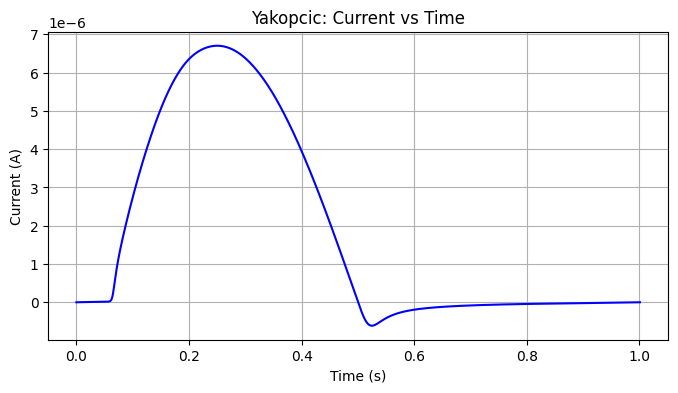

In [22]:
# Βήμα 5: Time-dependent Analysis
t = model_data['t'][0,0].flatten()  # time array
I = model_data['I'][0,0].flatten()  # current array

# Σχεδίαση Current vs Time
plt.figure(figsize=(8,4))
plt.plot(t, I, color='blue')
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.title("Yakopcic: Current vs Time")
plt.grid(True)
plt.show()


2025-09-27 07:07:19.895843: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758956840.099765      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758956840.159685      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Epoch 1/20


2025-09-27 07:07:33.964786: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0431 - val_loss: 9.4217e-07
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.4286e-05 - val_loss: 6.7103e-07
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.8563e-05 - val_loss: 6.4868e-07
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.7635e-05 - val_loss: 5.0694e-07
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.7241e-05 - val_loss: 2.8007e-07
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.6590e-05 - val_loss: 1.6932e-06
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.5191e-05 - val_loss: 7.2762e-07
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.4139e-05 - val_loss: 4.9873e-08
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.3704e-05 - val_loss: 4.0154e-08
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.1751e-05 - val_loss: 1.9988e-07
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.0485e-05 -

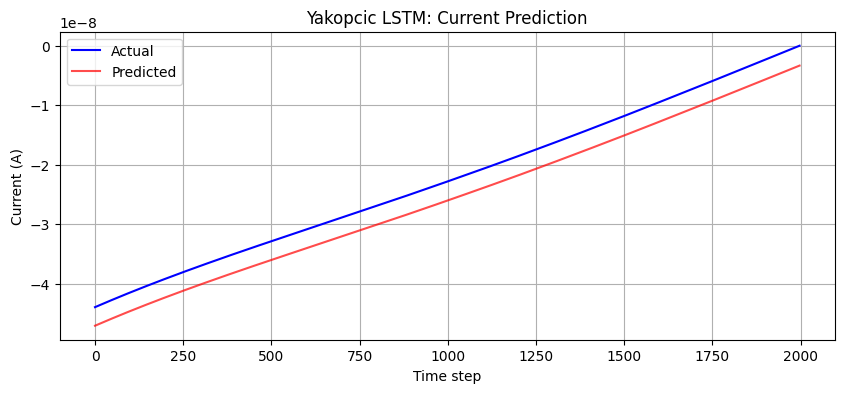

In [23]:
# Libraries
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Χρήση Current vs Time
I = model_data['I'][0,0].flatten()
I = I.reshape(-1,1)  # reshaping για scaler

# Κλίμακα δεδομένων (0-1)
scaler = MinMaxScaler(feature_range=(0,1))
I_scaled = scaler.fit_transform(I)

# Δημιουργία sequences (windowed data)
def create_sequences(data, window_size=20):
    X, y = [], []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 20
X_seq, y_seq = create_sequences(I_scaled, window_size)

# Διαχωρισμός train/test
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# LSTM model
model = Sequential()
model.add(LSTM(50, input_shape=(window_size, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Εκπαίδευση
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

# Πρόβλεψη
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

# Σχεδίαση predicted vs actual
plt.figure(figsize=(10,4))
plt.plot(y_test_inv, label="Actual", color='blue')
plt.plot(y_pred_inv, label="Predicted", color='red', alpha=0.7)
plt.xlabel("Time step")
plt.ylabel("Current (A)")
plt.title("Yakopcic LSTM: Current Prediction")
plt.legend()
plt.grid(True)
plt.show()


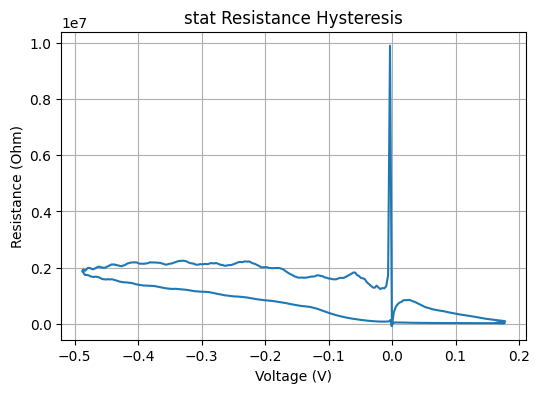

stat Switching threshold: 3.688e+05 Ohm


In [25]:
R = V / I
plt.figure(figsize=(6,4))
plt.plot(V, R, label="R-V Curve")
plt.xlabel("Voltage (V)")
plt.ylabel("Resistance (Ohm)")
plt.title(f"{model_name} Resistance Hysteresis")
plt.grid(True)
plt.show()

# Switching threshold (π.χ. median R change)
switch_threshold = np.median(R)
print(f"{model_name} Switching threshold: {switch_threshold:.3e} Ohm")


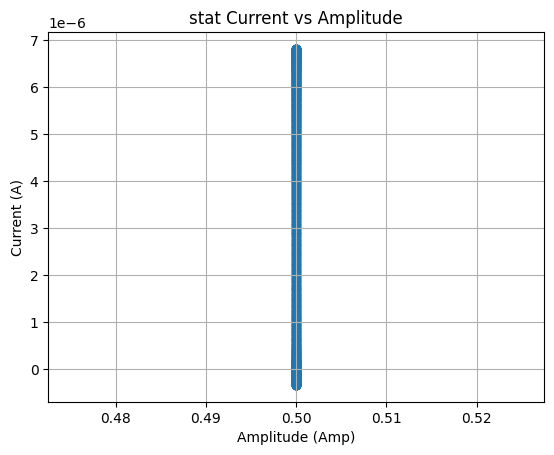

In [27]:
# Αν Amp έχει μόνο μία τιμή:
Amp_val = model_data['Amp'][0,0].flatten()[0]  # παίρνουμε μόνο την πρώτη τιμή
plt.scatter([Amp_val]*len(I), I)
plt.xlabel("Amplitude (Amp)")
plt.ylabel("Current (A)")
plt.title(f"{model_name} Current vs Amplitude")
plt.grid(True)
plt.show()


In [30]:
# Example: 3 classes
labels = np.digitize(R, bins=[np.percentile(R,33), np.percentile(R,66)])
# Train/test split και RandomForestClassifier όπως προηγουμένως


In [32]:
import numpy as np

# Επαναλαμβάνουμε Amp ώστε να ταιριάζει με το μέγεθος του I
Amp_val = Amp[0]  # παίρνουμε την πρώτη/μοναδική τιμή
Amp_full = np.full_like(I, fill_value=Amp_val, dtype=float)

# Δημιουργία multi-feature array
features = np.column_stack([I, V, Amp_full])
print(features.shape)  # τώρα θα είναι (1001, 3)


(1001, 3)


In [33]:
features = np.column_stack([I, V])


In [35]:
import numpy as np

# Αν Amp είναι μοναδική τιμή
Amp_val = Amp[0]                # παίρνουμε την πρώτη τιμή
Amp_full = np.full_like(I, Amp_val, dtype=float)  # επαναλαμβάνουμε σε ίδιο μέγεθος

# Δημιουργία multi-feature array
features = np.column_stack([I, V, Amp_full])
print("Shape of features:", features.shape)  # π.χ. (1001, 3)

# Στη συνέχεια μπορούμε να φτιάξουμε sequences για LSTM
def create_sequences(data, window_size=20):
    X, y = [], []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size, 0])  # προβλέπουμε το I
    return np.array(X), np.array(y)

window_size = 20
X_seq, y_seq = create_sequences(features, window_size)
print("X_seq shape:", X_seq.shape, "y_seq shape:", y_seq.shape)



Shape of features: (1001, 3)
X_seq shape: (981, 20, 3) y_seq shape: (981,)


In [37]:
def get_voltage_current(model_name):
    model_data = mem_data[model_name][0,0]
    if model_name == 'stat':
        V = model_data['U_m_b_interp'][0,0].flatten()
        I = model_data['I_m_b_interp'][0,0].flatten()
    else:
        V = model_data['V'][0,0].flatten()
        I = model_data['I'][0,0].flatten()
    return V, I



=== MODEL: Yakopcic ===
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0477 - val_loss: 8.2910e-05
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.1998e-05 - val_loss: 4.9980e-05
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.1061e-05 - val_loss: 4.0815e-05
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 8.7138e-06 - val_loss: 3.0538e-05
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7.4799e-06 - val_loss: 2.0998e-05
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 6.5755e-06 - val_loss: 1.2339e-05
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 6.0094e-06 - val_loss: 1.4112e-05
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4.9414e-06 - val_loss: 8.1081e-06
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4.3614e-06 - val_loss: 8.5874e-06
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4.2217e-06 - val_loss: 8.4576e-06
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.4880e-06 -

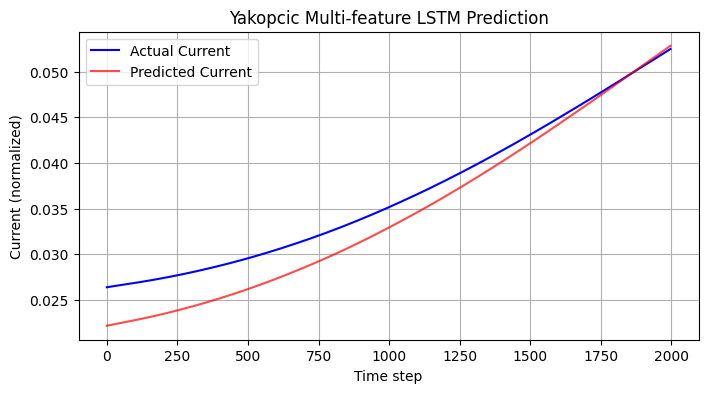


=== MODEL: MMS ===
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0275 - val_loss: 2.7492e-05
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.5766e-05 - val_loss: 4.8467e-06
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.0755e-05 - val_loss: 1.5491e-06
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7.5103e-06 - val_loss: 1.7882e-08
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5.9149e-06 - val_loss: 3.6615e-07
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4.3550e-06 - val_loss: 1.6772e-06
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.2444e-06 - val_loss: 2.2032e-06
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.5913e-06 - val_loss: 1.7748e-06
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.1785e-06 - val_loss: 1.1593e-06
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.3887e-06 - val_loss: 8.6289e-07
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.0614e-06 -

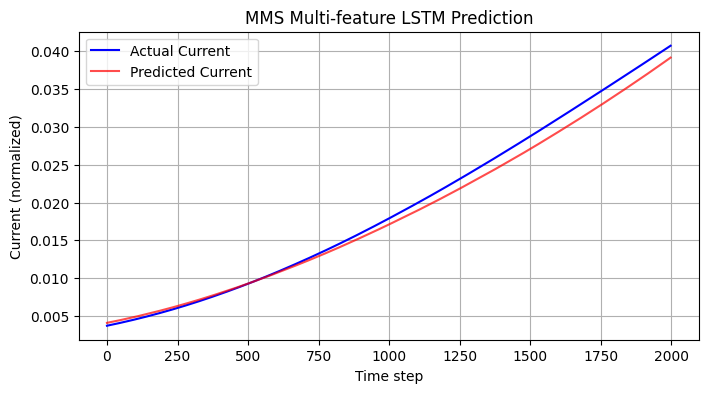


=== MODEL: stat ===
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.1876 - val_loss: 0.0035
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0092 - val_loss: 6.9438e-05
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0012 - val_loss: 9.0378e-06
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 8.3217e-04 - val_loss: 6.6851e-05
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.4867e-04 - val_loss: 1.3649e-04
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.5193e-04 - val_loss: 1.5519e-04
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.2935e-04 - val_loss: 1.8861e-04
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.8931e-04 - val_loss: 1.3348e-04
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.9701e-04 - val_loss: 2.0529e-04
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.1966e-04 - val_loss: 2.2224e-04
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.5135e-04 - val_loss: 1.6744e-04
Ep

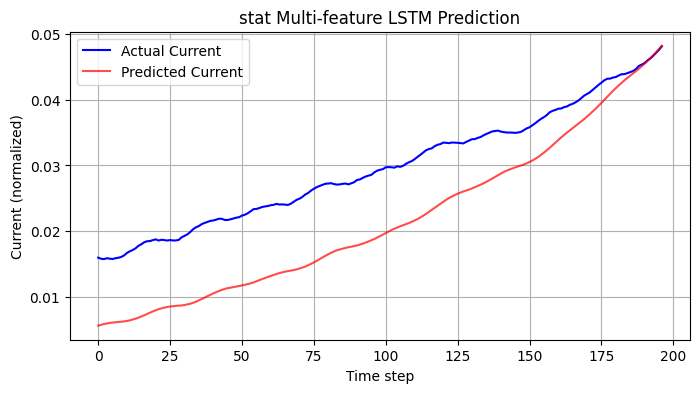


=== MODEL: VTEAM ===
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0793 - val_loss: 3.4254e-05
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.8002e-05 - val_loss: 1.7943e-05
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.5163e-05 - val_loss: 4.8691e-06
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.1500e-05 - val_loss: 2.5414e-06
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 9.0641e-06 - val_loss: 6.2694e-07
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 6.9767e-06 - val_loss: 7.4454e-08
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5.8924e-06 - val_loss: 7.9843e-08
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 4.2711e-06 - val_loss: 3.5226e-07
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3.7663e-06 - val_loss: 8.5941e-08
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.9205e-06 - val_loss: 1.9546e-07
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.0464e-06 -

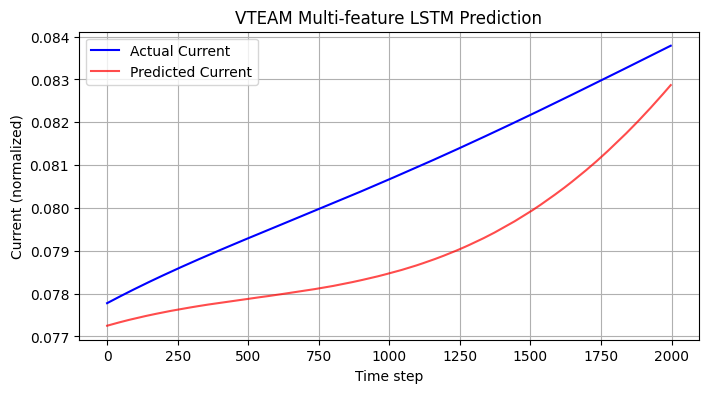

In [40]:
# Multi-feature LSTM pipeline for all 4 memristor models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split

# Models
models = ['Yakopcic', 'MMS', 'stat', 'VTEAM']

# Function to get voltage and current per model
def get_voltage_current(model_name):
    model_data = mem_data[model_name][0,0]
    if model_name == 'stat':
        V = model_data['U_m_b_interp'][0,0].flatten()
        I = model_data['I_m_b_interp'][0,0].flatten()
    else:
        V = model_data['V'][0,0].flatten()
        I = model_data['I'][0,0].flatten()
    return V, I, model_data

# Function to create sequences for LSTM
def create_sequences(data, window_size=20):
    X, y = [], []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size, 0])  # target: next current
    return np.array(X), np.array(y)

# Loop over all models
for model_name in models:
    print(f"\n=== MODEL: {model_name} ===")
    
    V, I, model_data = get_voltage_current(model_name)
    
    # Handle Amp feature
    Amp_val = model_data['Amp'][0,0].flatten()[0]  # take first value
    Amp_full = np.full_like(I, Amp_val, dtype=float)
    
    # Multi-feature array
    features = np.column_stack([I, V, Amp_full])
    
    # Normalize features
    scaler = MinMaxScaler(feature_range=(0,1))
    features_scaled = scaler.fit_transform(features)
    
    # Create sequences
    window_size = 20
    X_seq, y_seq = create_sequences(features_scaled, window_size)
    
    # Train/test split
    split = int(0.8 * len(X_seq))
    X_train, X_test = X_seq[:split], X_seq[split:]
    y_train, y_test = y_seq[:split], y_seq[split:]
    
    # LSTM model
    lstm_model = Sequential()
    lstm_model.add(LSTM(50, input_shape=(window_size, features_scaled.shape[1])))
    lstm_model.add(Dense(1))
    lstm_model.compile(optimizer='adam', loss='mse')
    
    # Train
    lstm_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)
    
    # Predict
    y_pred = lstm_model.predict(X_test)
    
    # Plot Actual vs Predicted
    plt.figure(figsize=(8,4))
    plt.plot(y_test, label="Actual Current", color='blue')
    plt.plot(y_pred, label="Predicted Current", color='red', alpha=0.7)
    plt.xlabel("Time step")
    plt.ylabel("Current (normalized)")
    plt.title(f"{model_name} Multi-feature LSTM Prediction")
    plt.legend()
    plt.grid(True)
    plt.show()
